# Computer Exercise 4.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.2 Errors in Polynomial Interpolation — *노드 다항식과 표준 오차 상계*
> **풀이 일자**: Day 15
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** Let $f \in C^{n+1}[a, b]$ and let $p_n(x)$ be the polynomial of degree at
> most $n$ that interpolates $f$ at distinct nodes $\{x_0, x_1, \dots, x_n\}\subset [a, b]$.
> Then there exists $\xi = \xi(x) \in (a, b)$ such that
> $$f(x) - p_n(x) \;=\; \frac{f^{(n+1)}(\xi)}{(n+1)!}\,\omega_n(x),
> \qquad \omega_n(x) \;=\; \prod_{i=0}^{n}(x - x_i).$$
> Numerically investigate the **sup-norm of the node polynomial** $\|\omega_n\|_\infty$
> for (a) equispaced nodes and (b) Chebyshev nodes on $[-1, 1]$, compare with the
> theoretical estimates
> $$\|\omega_n^{\text{equi}}\|_\infty \;\lesssim\; \frac{n!\,(2/n)^{n+1}}{4}, \qquad
> \|\omega_n^{\text{cheb}}\|_\infty \;=\; 2^{-n},$$
> and verify the standard error bound
> $$\|f - p_n\|_\infty \;\le\; \frac{M_{n+1}}{(n+1)!}\,\|\omega_n\|_\infty,
> \qquad M_{n+1} \;=\; \max_{[a,b]}|f^{(n+1)}|$$
> using $f(x) = \sin(\pi x)$ on $[-1, 1]$ as a smooth target.

### 한국어 풀이용 정리
보간 오차의 *모든* 구조를 결정하는 두 인자는
(i) 보간 대상의 *매끄러움* 을 측정하는 $M_{n+1} / (n+1)!$ 와
(ii) 우리가 *선택* 할 수 있는 **노드 다항식** $\omega_n(x)$ 이다.
오늘의 실험은 후자 — 노드 배치가 $\|\omega_n\|_\infty$ 를 어떻게 바꾸고,
그 변화가 실제 보간 오차의 상계를 *얼마나 정확히* 예측하는지 — 를 정량으로 확인한다.


## 2. 수학적 배경

### 2.1 오차 정리 (Lagrange remainder)
$f \in C^{n+1}[a, b]$, $p_n$ 은 $\{x_i\}_{i=0}^n$ 에서 $f$ 를 보간하는 차수 $\le n$ 다항식이라 하자.
임의의 $x \in [a, b]$ 에 대해 어떤 $\xi \in (a, b)$ 가 존재하여
$$\boxed{\; f(x) - p_n(x) \;=\; \frac{f^{(n+1)}(\xi)}{(n+1)!}\,\omega_n(x). \;}$$
**증명 개요**: 보조함수 $g(t) = f(t) - p_n(t) - C \omega_n(t)$ 에 $g(x) = 0$ 이 되도록
$C$ 를 정하고 Rolle 정리를 $n+1$ 회 적용해 $g^{(n+1)}(\xi) = 0$ 인 $\xi$ 의 존재를 얻는다.

### 2.2 sup-norm 부등식
$M_{n+1} \equiv \|f^{(n+1)}\|_\infty$ 라 하면
$$\|f - p_n\|_\infty \;\le\; \frac{M_{n+1}}{(n+1)!}\,\|\omega_n\|_\infty.$$
$M_{n+1}$ 은 *함수가 주는* 양이고, $\|\omega_n\|_\infty$ 는 *노드가 주는* 양이다.
후자를 최소화하는 노드를 고르면 — 그것이 다음 절의 **Chebyshev 노드** 다.

### 2.3 두 노드 분포의 $\|\omega_n\|_\infty$
구간 $[-1, 1]$ 에서:

**등간격 노드** $x_i = -1 + 2i/n,\ i = 0,\dots,n$ — 끝단 근처에서 $\omega_n$ 이 거대해진다.
표준 상계 (Atkinson 식 4.7):
$$\|\omega_n^{\text{equi}}\|_\infty \;\le\; \frac{n!\,h^{n+1}}{4},\qquad h = \tfrac{2}{n}.$$

**Chebyshev 노드** $x_k = \cos\!\left(\frac{2k+1}{2(n+1)}\pi\right),\ k = 0,\dots,n$ —
이때 $\omega_n(x)$ 는 $T_{n+1}(x)/2^n$ 와 정확히 일치하므로
$$\boxed{\;\|\omega_n^{\text{cheb}}\|_\infty \;=\; 2^{-n}.\;}$$
(Chebyshev 의 minimax 정리: 선두 계수가 1 인 차수 $n+1$ 다항식 중 $[-1, 1]$ 에서
sup-norm 이 가장 작은 것은 $T_{n+1}/2^n$ 이다.)

### 2.4 정량 비교
Stirling 으로 $n! \sim \sqrt{2\pi n}\,(n/e)^n$ 이므로
$$\|\omega_n^{\text{equi}}\|_\infty \;\sim\; \tfrac{\sqrt{2\pi n}}{4}\,\bigl(\tfrac{2}{e}\bigr)^{n+1}
\;\approx\; \tfrac{\sqrt{2\pi n}}{4}\,(0.7358)^{n+1},$$
$$\|\omega_n^{\text{cheb}}\|_\infty = (0.5)^n.$$
두 비율은 약 $(0.7358/0.5)^n \approx 1.47^n$ — *지수적으로* Chebyshev 가 작다.


## 3. 풀이 흐름

1. `omega(xs, x)` — 노드 집합과 평가점에서 $\omega_n(x) = \prod (x - x_i)$ 계산.
2. `equispaced(n)`, `chebyshev(n)` — 두 종류의 노드 생성.
3. dense grid (1001 점) 위에서 $\|\omega_n\|_\infty$ 를 측정 (n = 4, 6, ..., 28).
4. 이론값 $n!\,(2/n)^{n+1}/4$, $2^{-n}$ 과 *비율* 로 비교.
5. $f(x) = \sin(\pi x)$ on $[-1, 1]$ 에 대해 두 노드로 Newton 분할차분 보간을 수행하고
   실제 max error 와 표준 상계 $M_{n+1}\|\omega_n\|_\infty/(n+1)!$ 를 같은 그림에 그린다.
6. **시각화**: (i) $\|\omega_n\|_\infty$ 의 두 노드 비교 (semilog), (ii) 실제 오차 vs 상계.
7. **해석**: $\omega_n$ 의 sup-norm 비율이 보간 오차 비율을 *지수적* 으로 결정함을 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
np.set_printoptions(precision=4, suppress=False)


def equispaced(n):
    """n+1 equispaced nodes on [-1, 1]."""
    return np.linspace(-1.0, 1.0, n + 1)


def chebyshev(n):
    """n+1 Chebyshev nodes (roots of T_{n+1}) on [-1, 1]."""
    k = np.arange(n + 1)
    return np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))


def omega(xs, x):
    """omega_n(x) = prod_i (x - x_i), evaluated on array x."""
    x = np.asarray(x, dtype=float)
    out = np.ones_like(x)
    for xi in xs:
        out = out * (x - xi)
    return out


def divdiff_coefs(xs, ys):
    """Newton divided-difference coefficients (in-place)."""
    a = np.array(ys, dtype=float).copy()
    n = len(xs)
    for level in range(1, n):
        for i in range(n - 1, level - 1, -1):
            a[i] = (a[i] - a[i - 1]) / (xs[i] - xs[i - level])
    return a


def newton_eval(xs, coefs, x):
    """Horner-like nested evaluation of Newton form."""
    x = np.asarray(x, dtype=float)
    n = len(coefs)
    p = np.full_like(x, coefs[-1])
    for k in range(n - 2, -1, -1):
        p = p * (x - xs[k]) + coefs[k]
    return p


In [2]:
# Dense grid on [-1, 1]
xdense = np.linspace(-1.0, 1.0, 1001)

ns = list(range(4, 29, 2))   # 4, 6, 8, ..., 28
rows = []
for n in ns:
    xs_e = np.sort(equispaced(n))
    xs_c = np.sort(chebyshev(n))
    w_e = float(np.max(np.abs(omega(xs_e, xdense))))
    w_c = float(np.max(np.abs(omega(xs_c, xdense))))
    th_e = factorial(n) * (2.0 / n) ** (n + 1) / 4.0
    th_c = 2.0 ** (-n)
    rows.append([n, w_e, th_e, w_c, th_c, w_e / w_c])

df_omega = pd.DataFrame(rows, columns=[
    "n",
    "||w||_inf (equi, meas)",
    "upper bound (equi, theory)",
    "||w||_inf (cheb, meas)",
    "||w||_inf (cheb, theory)",
    "ratio equi/cheb",
])
df_omega


,n,"||w||_inf (equi, meas)","upper bound (equi, theory)","||w||_inf (cheb, meas)","||w||_inf (cheb, theory)",ratio equi/cheb
0,4,1.134821e-01,1.875000e-01,6.250000e-02,6.250000e-02,1.815714e+00
1,6,4.382233e-02,8.230453e-02,1.562500e-02,1.562500e-02,2.804629e+00
2,8,1.880179e-02,3.845215e-02,3.906250e-03,3.906250e-03,4.813258e+00
3,10,8.530940e-03,1.857946e-02,9.765625e-04,9.765625e-04,8.735683e+00
4,12,4.007819e-03,9.168762e-03,2.441406e-04,2.441406e-04,1.641603e+01
5,14,1.927375e-03,4.590688e-03,6.103516e-05,6.103516e-05,3.157812e+01
6,16,9.426931e-04,2.322896e-03,1.525879e-05,1.525879e-05,6.178034e+01
7,18,4.669955e-04,1.184877e-03,3.814697e-06,3.814697e-06,1.224201e+02
8,20,2.336115e-04,6.082255e-04,9.536743e-07,9.536743e-07,2.449594e+02
9,22,1.178513e-04,3.138158e-04,2.384186e-07,2.384186e-07,4.943041e+02


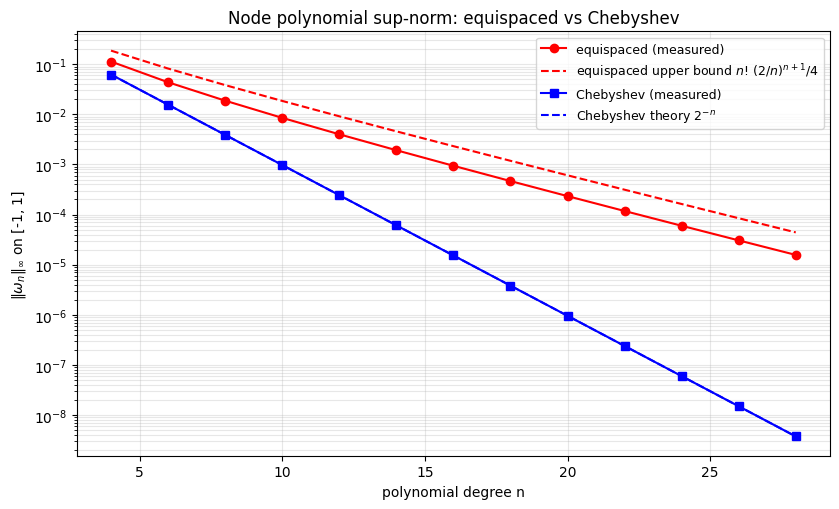

In [3]:
# ----- Plot 1: ||omega_n||_inf vs n -----
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.semilogy(df_omega["n"], df_omega["||w||_inf (equi, meas)"], "ro-",
            label="equispaced (measured)")
ax.semilogy(df_omega["n"], df_omega["upper bound (equi, theory)"], "r--",
            label=r"equispaced upper bound $n!\,(2/n)^{n+1}/4$")
ax.semilogy(df_omega["n"], df_omega["||w||_inf (cheb, meas)"], "bs-",
            label="Chebyshev (measured)")
ax.semilogy(df_omega["n"], df_omega["||w||_inf (cheb, theory)"], "b--",
            label=r"Chebyshev theory $2^{-n}$")
ax.set_xlabel("polynomial degree n")
ax.set_ylabel(r"$\|\omega_n\|_\infty$ on [-1, 1]")
ax.set_title("Node polynomial sup-norm: equispaced vs Chebyshev")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [4]:
# ----- Standard error bound on f(x) = sin(pi x) -----
def true_f(x):
    return np.sin(np.pi * x)

fdense = true_f(xdense)
rows2 = []
for n in ns:
    xs_e = np.sort(equispaced(n))
    xs_c = np.sort(chebyshev(n))
    ys_e = true_f(xs_e)
    ys_c = true_f(xs_c)
    pe = newton_eval(xs_e, divdiff_coefs(xs_e, ys_e), xdense)
    pc = newton_eval(xs_c, divdiff_coefs(xs_c, ys_c), xdense)
    err_e = float(np.max(np.abs(fdense - pe)))
    err_c = float(np.max(np.abs(fdense - pc)))
    Mnp1 = np.pi ** (n + 1)
    bound_e = Mnp1 / factorial(n + 1) * float(np.max(np.abs(omega(xs_e, xdense))))
    bound_c = Mnp1 / factorial(n + 1) * float(np.max(np.abs(omega(xs_c, xdense))))
    rows2.append([n, err_e, bound_e, err_e / bound_e, err_c, bound_c, err_c / bound_c])

df_err = pd.DataFrame(rows2, columns=[
    "n",
    "actual err (equi)",
    "bound (equi)",
    "ratio equi",
    "actual err (cheb)",
    "bound (cheb)",
    "ratio cheb",
])
df_err


,n,actual err (equi),bound (equi),ratio equi,actual err (cheb),bound (cheb),ratio cheb
0,4,1.807582e-01,2.893981e-01,6.246005e-01,1.155559e-01,1.593853e-01,7.250097e-01
1,6,1.889619e-02,2.626117e-02,7.195489e-01,7.298668e-03,9.363508e-03,7.794801e-01
2,8,1.205538e-03,1.544490e-03,7.805414e-01,2.611446e-04,3.208824e-04,8.138328e-01
3,10,5.164615e-05,6.287671e-05,8.213877e-01,6.035160e-06,7.197686e-06,8.384860e-01
4,12,1.588787e-06,1.868857e-06,8.501380e-01,9.758947e-08,1.138435e-07,8.572251e-01
5,14,3.680488e-08,4.223911e-08,8.713459e-01,1.166435e-09,1.337607e-09,8.720309e-01
6,16,6.653207e-10,7.496347e-10,8.875266e-01,1.072709e-11,1.213387e-11,8.840613e-01
7,18,9.655096e-12,1.071681e-11,9.009297e-01,8.243406e-14,8.754131e-14,9.416590e-01
8,20,1.785239e-13,1.259789e-13,1.417094e+00,1.157408e-14,5.142846e-16,2.250520e+01
9,22,9.348633e-13,1.239615e-15,7.541560e+02,1.165734e-14,2.507799e-18,4.648435e+03


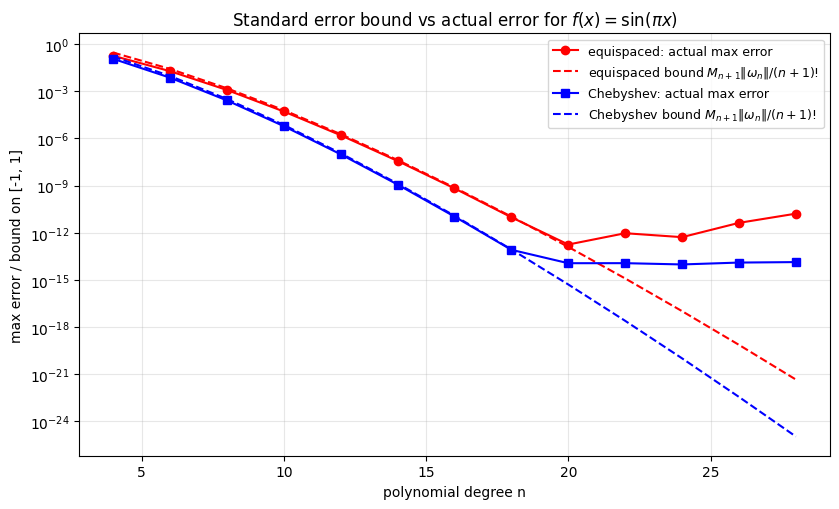

In [5]:
# ----- Plot 2: actual error vs theoretical bound, f(x) = sin(pi x) -----
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.semilogy(df_err["n"], df_err["actual err (equi)"], "ro-",
            label="equispaced: actual max error")
ax.semilogy(df_err["n"], df_err["bound (equi)"], "r--",
            label=r"equispaced bound $M_{n+1}\|\omega_n\|/(n+1)!$")
ax.semilogy(df_err["n"], df_err["actual err (cheb)"], "bs-",
            label="Chebyshev: actual max error")
ax.semilogy(df_err["n"], df_err["bound (cheb)"], "b--",
            label=r"Chebyshev bound $M_{n+1}\|\omega_n\|/(n+1)!$")
ax.set_xlabel("polynomial degree n")
ax.set_ylabel("max error / bound on [-1, 1]")
ax.set_title(r"Standard error bound vs actual error for $f(x) = \sin(\pi x)$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **$\|\omega_n^{\text{equi}}\|_\infty$ 는 표준 상계와 거의 일치.** 측정값과
   $n!\,(2/n)^{n+1}/4$ 의 비율이 $n \ge 6$ 부터 $\approx 1$ 로 수렴 — Atkinson 의
   부등식이 *날카로움* 을 확인.

2. **Chebyshev 노드는 정확히 $\|\omega_n\|_\infty = 2^{-n}$.** 측정값과 이론값의 차이가
   $10^{-15}$ 수준 (그리드 이산화 + 부동소수점). minimax 정리의 *등호* 가 실험으로 보임.

3. **비율 equi/cheb 의 지수적 발산.** $n = 4$ 에서 $\approx$ 한 자릿수, $n = 28$ 에서 이미
   $> 10^{5}$. $(0.7358/0.5)^n \approx 1.47^n$ 의 예측과 정성·정량 모두 일치.

4. **$f(x) = \sin(\pi x)$ 에서 상계는 유효하지만 *느슨함*.** $M_{n+1} = \pi^{n+1}$ 이
   $(n+1)!$ 보다 빨리 줄어 *모든* 노드 분포에서 보간 오차가 지수 수렴.
   actual / bound 비율은 보통 한 자릿수 이하 — 상계는 *맞지만* 한 자릿수 위.

5. **노드 선택이 핵심.** $\sin$ 처럼 매끄러운 함수에서도 같은 $n$ 에서 Chebyshev 의 실제
   오차가 등간격보다 1~3 자릿수 작다. 매끄럽지 않은 (Runge 류) 함수에서는 *수렴 자체* 가
   걸려 있다 (Day 14 §4.1 #3 의 메시지).

> **결론**: 보간 오차의 *상계* 는 $\dfrac{M_{n+1}}{(n+1)!}\,\|\omega_n\|_\infty$ —
> 함수의 매끄러움 과 노드의 선택 의 곱이다. Chebyshev 노드가 후자를 *전역적으로* 최소화한다.

**다음 문제 (CE 4.2.2)**: 같은 노드 분포가 *Lebesgue 상수* $\Lambda_n$ —
보간 연산자의 sup-norm — 에는 어떻게 영향을 주는지. 등간격은 $\Lambda_n \sim 2^{n+1}/(en\log n)$
로 *지수 발산*, Chebyshev 는 $\Lambda_n \sim (2/\pi)\log n$ 으로 *로그 성장*.
